# e) Benders decomposition

In [176]:
def compute_benders_duals(c, f, y):
    # - v: how much of each product each region gets
    # - w: how much each DC ships to each region for each product
    # - shipping: total shipping cost
    # - fixed: total cost to open the chosen DCs
    # - cut_rhs: the same as the total shipping cost
    # - coef: for each DC, its fixed cost minus the shipping it handles
    I = list(c.keys())
    J = list(c[I[0]].keys())
    K = list(c[I[0]][J[0]].keys())
    
    # 1) Compute v[j][k] = min over open i of c[i][j][k]
    v = {j: {} for j in J}
    for j in J:
        for k in K:
            # collect costs only on open DCs
            costs = [c[i][j][k] for i in I if y[i] == 1]
            if not costs:
                raise ValueError(f"No open DC to cover region {j}, product {k}")
            v[j][k] = min(costs)
    
    # 2) Compute w[i][j][k] = max(0, v[j][k] - c[i][j][k])
    w = {i: {j: {} for j in J} for i in I}
    for i in I:
        for j in J:
            for k in K:
                w[i][j][k] = max(0, v[j][k] - c[i][j][k])
                
                
    
    # 3) Shipping cost = sum_jk v[j][k]
    shipping = sum(v[j][k] for j in J for k in K)
    
    # 4) Fixed cost = sum_i f[i]*y[i]
    fixed = sum(f[i] * y[i] for i in I)
    
    # 5) Benders cut: RHS = shipping + fixed,
    #    coefficients on y[i] are (f[i] - sum_jk w[i][j][k])
    cut_rhs = shipping
    coef    = {i: f[i] - sum(w[i][j][k] for j in J for k in K) for i in I}
    
    return v, w, shipping, fixed, cut_rhs, coef


# ---- Example usage ----
if __name__ == "__main__":
    # Index sets
    I = [1,2,3]
    J = [1,2,3,4,5]
    K = [1,2]
    
    # Costs from the table: c[i][j][k]
    c = {
      1: {1:{1:2, 2:4}, 2:{1:3,2:1}, 3:{1:4,2:2}, 4:{1:5,2:5}, 5:{1:7,2:2}},
      2: {1:{1:4, 2:3}, 2:{1:3,2:1}, 3:{1:1,2:1}, 4:{1:2,2:5}, 5:{1:6,2:3}},
      3: {1:{1:5, 2:2}, 2:{1:4,2:5}, 3:{1:2,2:2}, 4:{1:1,2:3}, 5:{1:3,2:3}}
    }
    f = {1:2, 2:3, 3:3}
    
    
    y = {1:1, 2:0, 3:0}
    
    v, w, shipping, fixed, rhs, coef = compute_benders_duals(c, f, y)
    
    print("v[j][k]:")
    for j in J:
        print(" region", j, [v[j][k] for k in K])
    print("shipping cost =", shipping)
    print("fixed cost    =", fixed)
    print("cut rhs =", rhs)
    print("cut coefficients on y[i]:", coef)
    print("UB = ", fixed + shipping)



v[j][k]:
 region 1 [2, 4]
 region 2 [3, 1]
 region 3 [4, 2]
 region 4 [5, 5]
 region 5 [7, 2]
shipping cost = 35
fixed cost    = 2
cut rhs = 35
cut coefficients on y[i]: {1: 2, 2: -6, 3: -11}
UB =  37


In [156]:
import gurobipy as gp
from gurobipy import GRB

f = {1: 2, 2: 3, 3: 3}  # fixed costs

# --- Build the model ---
m = gp.Model("master")

# Decision variables
y = m.addVars([1,2,3], vtype=GRB.BINARY, name="y")
y1 = y[1]
y2 = y[2]
y3 = y[3]

theta = m.addVar(lb=-GRB.INFINITY, name="theta")

# Objective
m.setObjective(
    theta,
    GRB.MINIMIZE
)

# Benders cut from Iteration 1
m.addConstr(
    theta >= 35 + 2*y1 - 6*y2 - 11*y3,
    name="benders_cut1"
)
m.setParam('OutputFlag', 0)
# --- Solve ---
m.optimize()

# --- results ---
if m.status == GRB.OPTIMAL:
    print(f"Objective (LB) = {m.objVal:.2f}")
    print(f"y1 = {int(y1.x)}, y2 = {int(y2.x)}, y3 = {int(y3.x)}")
    print(f"theta = {theta.x:.2f}")
else:
    print("No optimal solution found.")


Objective (LB) = 18.00
y1 = 0, y2 = 1, y3 = 1
theta = 18.00


In [174]:
def compute_benders_duals(c, f, y):
    # - v: how much of each product each region gets
    # - w: how much each DC ships to each region for each product
    # - shipping: total shipping cost
    # - fixed: total cost to open the chosen DCs
    # - cut_rhs: the same as the total shipping cost
    # - coef: for each DC, its fixed cost minus the shipping it handles
    I = list(c.keys())
    J = list(c[I[0]].keys())
    K = list(c[I[0]][J[0]].keys())
    
    # 1) Compute v[j][k] = min over open i of c[i][j][k]
    v = {j: {} for j in J}
    for j in J:
        for k in K:
            # collect costs only on open DCs
            costs = [c[i][j][k] for i in I if y[i] == 1]
            if not costs:
                raise ValueError(f"No open DC to cover region {j}, product {k}")
            v[j][k] = min(costs)
    
    # 2) Compute w[i][j][k] = max(0, v[j][k] - c[i][j][k])
    w = {i: {j: {} for j in J} for i in I}
    for i in I:
        for j in J:
            for k in K:
                w[i][j][k] = max(0, v[j][k] - c[i][j][k])
    
    # 3) Shipping cost = sum_jk v[j][k]
    shipping = sum(v[j][k] for j in J for k in K)
    
    # 4) Fixed cost = sum_i f[i]*y[i]
    fixed = sum(f[i] * y[i] for i in I)
    
    # 5) Benders cut: RHS = shipping + fixed,
    #    coefficients on y[i] are (f[i] - sum_jk w[i][j][k])
    cut_rhs = shipping
    coef    = {i: f[i] - sum(w[i][j][k] for j in J for k in K) for i in I}
    
    return v, w, shipping, fixed, cut_rhs, coef



# ---- Example usage ----
if __name__ == "__main__":
    # Index sets
    I = [1,2,3]
    J = [1,2,3,4,5]
    K = [1,2]
    
    # Costs from the table: c[i][j][k]
    c = {
      1: {1:{1:2, 2:4}, 2:{1:3,2:1}, 3:{1:4,2:2}, 4:{1:5,2:5}, 5:{1:7,2:2}},
      2: {1:{1:4, 2:3}, 2:{1:3,2:1}, 3:{1:1,2:1}, 4:{1:2,2:5}, 5:{1:6,2:3}},
      3: {1:{1:5, 2:2}, 2:{1:4,2:5}, 3:{1:2,2:2}, 4:{1:1,2:3}, 5:{1:3,2:3}}
    }
    f = {1:2, 2:3, 3:3}
    
    
    y = {1:0, 2:1, 3:1}
    
    v, w, shipping, fixed, rhs, coef = compute_benders_duals(c, f, y)
    
    print("v[j][k]:")
    for j in J:
        print(" region", j, [v[j][k] for k in K])
    print("shipping cost =", shipping)
    print("fixed cost    =", fixed)
    print("cut rhs =", rhs)
    print("cut coefficients on y[i]:", coef)
    print("UB = ", fixed + shipping)

v[j][k]:
 region 1 [4, 2]
 region 2 [3, 1]
 region 3 [1, 1]
 region 4 [1, 3]
 region 5 [3, 3]
shipping cost = 22
fixed cost    = 6
cut rhs = 22
cut coefficients on y[i]: {1: -1, 2: 3, 3: 3}
UB =  28


In [160]:
import gurobipy as gp
from gurobipy import GRB

f = {1: 2, 2: 3, 3: 3}  # fixed costs

# --- Build the model ---
m = gp.Model("master")

# Decision variables
y = m.addVars([1,2,3], vtype=GRB.BINARY, name="y")
y1 = y[1]
y2 = y[2]
y3 = y[3]

theta = m.addVar(lb=-GRB.INFINITY, name="theta")

# Objective
m.setObjective(
    theta,
    GRB.MINIMIZE
)

# Benders cut from Iteration 1
m.addConstr(
    theta >= 35 + 2*y1 - 6*y2 - 11*y3,
    name="benders_cut1"
)

# Benders cut from Iteration 2
m.addConstr(
    theta >= 22 - 1*y1 + 3*y2 + 3*y3,
    name="benders_cut2"
)

m.setParam('OutputFlag', 0)
# --- Solve ---
m.optimize()

# --- results ---
if m.status == GRB.OPTIMAL:
    print(f"Objective (LB) = {m.objVal:.2f}")
    print(f"y1 = {int(y1.x)}, y2 = {int(y2.x)}, y3 = {int(y3.x)}")
    print(f"theta = {theta.x:.2f}")
else:
    print("No optimal solution found.")



Objective (LB) = 25.00
y1 = 0, y2 = 0, y3 = 1
theta = 25.00


In [172]:
def compute_benders_duals(c, f, y):
    # - v: how much of each product each region gets
    # - w: how much each DC ships to each region for each product
    # - shipping: total shipping cost
    # - fixed: total cost to open the chosen DCs
    # - cut_rhs: the same as the total shipping cost
    # - coef: for each DC, its fixed cost minus the shipping it handles
    I = list(c.keys())
    J = list(c[I[0]].keys())
    K = list(c[I[0]][J[0]].keys())
    
    # 1) Compute v[j][k] = min over open i of c[i][j][k]
    v = {j: {} for j in J}
    for j in J:
        for k in K:
            # collect costs only on open DCs
            costs = [c[i][j][k] for i in I if y[i] == 1]
            if not costs:
                raise ValueError(f"No open DC to cover region {j}, product {k}")
            v[j][k] = min(costs)
    
    # 2) Compute w[i][j][k] = max(0, v[j][k] - c[i][j][k])
    w = {i: {j: {} for j in J} for i in I}
    for i in I:
        for j in J:
            for k in K:
                w[i][j][k] = max(0, v[j][k] - c[i][j][k])
    
    # 3) Shipping cost = sum_jk v[j][k]
    shipping = sum(v[j][k] for j in J for k in K)
    
    # 4) Fixed cost = sum_i f[i]*y[i]
    fixed = sum(f[i] * y[i] for i in I)
    
    # 5) Benders cut: RHS = shipping + fixed,
    #    coefficients on y[i] are (f[i] - sum_jk w[i][j][k])
    cut_rhs = shipping
    coef    = {i: f[i] - sum(w[i][j][k] for j in J for k in K) for i in I}
    
    return v, w, shipping, fixed, cut_rhs, coef


# ---- Example usage ----
if __name__ == "__main__":
    # Index sets
    I = [1,2,3]
    J = [1,2,3,4,5]
    K = [1,2]
    
    # Costs from the table: c[i][j][k]
    c = {
      1: {1:{1:2, 2:4}, 2:{1:3,2:1}, 3:{1:4,2:2}, 4:{1:5,2:5}, 5:{1:7,2:2}},
      2: {1:{1:4, 2:3}, 2:{1:3,2:1}, 3:{1:1,2:1}, 4:{1:2,2:5}, 5:{1:6,2:3}},
      3: {1:{1:5, 2:2}, 2:{1:4,2:5}, 3:{1:2,2:2}, 4:{1:1,2:3}, 5:{1:3,2:3}}
    }
    
    f = {1:2, 2:3, 3:3}
    
    
    y = {1:0, 2:0, 3:1}
    
    v, w, shipping, fixed, rhs, coef = compute_benders_duals(c, f, y)
    
    print("v[j][k]:")
    for j in J:
        print(" region", j, [v[j][k] for k in K])
    print("shipping cost =", shipping)
    print("fixed cost    =", fixed)
    print("cut rhs =", rhs)
    print("cut coefficients on y[i]:", coef)
    print("UB = ", fixed + shipping)

v[j][k]:
 region 1 [5, 2]
 region 2 [4, 5]
 region 3 [2, 2]
 region 4 [1, 3]
 region 5 [3, 3]
shipping cost = 30
fixed cost    = 3
cut rhs = 30
cut coefficients on y[i]: {1: -7, 2: -5, 3: 3}
UB =  33


In [164]:
import gurobipy as gp
from gurobipy import GRB

f = {1: 2, 2: 3, 3: 3}  # fixed costs

# --- Build the model ---
m = gp.Model("master")

# Decision variables
y = m.addVars([1,2,3], vtype=GRB.BINARY, name="y")
y1 = y[1]
y2 = y[2]
y3 = y[3]

theta = m.addVar(lb=-GRB.INFINITY, name="theta")

# Objective
m.setObjective(
    theta,
    GRB.MINIMIZE
)

# Benders cut from Iteration 1
m.addConstr(
    theta >= 35 + 2*y1 - 6*y2 - 11*y3,
    name="benders_cut1"
)

# Benders cut from Iteration 2
m.addConstr(
    theta >= 22 - 1*y1 + 3*y2 + 3*y3,
    name="benders_cut2"
)

# Benders cut from Iteration 3
m.addConstr(
    theta >= 30 - 7*y1 - 5*y2 + 3*y3,
    name="benders_cut3"
)

m.setParam('OutputFlag', 0) 
# --- Solve ---
m.optimize()

# --- results ---
if m.status == GRB.OPTIMAL:
    print(f"Objective (LB) = {m.objVal:.2f}")
    print(f"y1 = {int(y1.x)}, y2 = {int(y2.x)}, y3 = {int(y3.x)}")
    print(f"theta = {theta.x:.2f}")
else:
    print("No optimal solution found.")

Objective (LB) = 26.00
y1 = 1, y2 = 0, y3 = 1
theta = 26.00


In [170]:
def compute_benders_duals(c, f, y):
    # - v: how much of each product each region gets
    # - w: how much each DC ships to each region for each product
    # - shipping: total shipping cost
    # - fixed: total cost to open the chosen DCs
    # - cut_rhs: the same as the total shipping cost
    # - coef: for each DC, its fixed cost minus the shipping it handles
    I = list(c.keys())
    J = list(c[I[0]].keys())
    K = list(c[I[0]][J[0]].keys())
    
    # 1) Compute v[j][k] = min over open i of c[i][j][k]
    v = {j: {} for j in J}
    for j in J:
        for k in K:
            # collect costs only on open DCs
            costs = [c[i][j][k] for i in I if y[i] == 1]
            if not costs:
                raise ValueError(f"No open DC to cover region {j}, product {k}")
            v[j][k] = min(costs)
    
    # 2) Compute w[i][j][k] = max(0, v[j][k] - c[i][j][k])
    w = {i: {j: {} for j in J} for i in I}
    for i in I:
        for j in J:
            for k in K:
                w[i][j][k] = max(0, v[j][k] - c[i][j][k])
    
    # 3) Shipping cost = sum_jk v[j][k]
    shipping = sum(v[j][k] for j in J for k in K)
    
    # 4) Fixed cost = sum_i f[i]*y[i]
    fixed = sum(f[i] * y[i] for i in I)
    
    # 5) Benders cut: RHS = shipping + fixed,
    #    coefficients on y[i] are (f[i] - sum_jk w[i][j][k])
    cut_rhs = shipping
    coef    = {i: f[i] - sum(w[i][j][k] for j in J for k in K) for i in I}
    
    return v, w, shipping, fixed, cut_rhs, coef


# ---- Example usage ----
if __name__ == "__main__":
    # Index sets
    I = [1,2,3]
    J = [1,2,3,4,5]
    K = [1,2]
    
    # Costs from the table: c[i][j][k]
    c = {
      1: {1:{1:2, 2:4}, 2:{1:3,2:1}, 3:{1:4,2:2}, 4:{1:5,2:5}, 5:{1:7,2:2}},
      2: {1:{1:4, 2:3}, 2:{1:3,2:1}, 3:{1:1,2:1}, 4:{1:2,2:5}, 5:{1:6,2:3}},
      3: {1:{1:5, 2:2}, 2:{1:4,2:5}, 3:{1:2,2:2}, 4:{1:1,2:3}, 5:{1:3,2:3}}
    }
    f = {1:2, 2:3, 3:3}
    
    
    y = {1:1, 2:0, 3:1}
    
    v, w, shipping, fixed, rhs, coef = compute_benders_duals(c, f, y)
    
    print("v[j][k]:")
    for j in J:
        print(" region", j, [v[j][k] for k in K])
    print("shipping cost =", shipping)
    print("fixed cost    =", fixed)
    print("cut rhs =", rhs)
    print("cut coefficients on y[i]:", coef)
    print("UB = ", fixed + shipping)

v[j][k]:
 region 1 [2, 2]
 region 2 [3, 1]
 region 3 [2, 2]
 region 4 [1, 3]
 region 5 [3, 2]
shipping cost = 21
fixed cost    = 5
cut rhs = 21
cut coefficients on y[i]: {1: 2, 2: 1, 3: 3}
UB =  26


# f) Dantzig Wolfe Decomposition

In [195]:
import gurobipy as gp
from gurobipy import GRB

# --- 1) Data ---
cost = [
    [2, 4],
    [3, 1],
    [4, 2],
    [5, 5],
    [7, 2],
]
num_clients = 5
num_products = 2

# --- 2) Initial pattern: all-ones ---
patterns = [ [[1]*num_products for _ in range(num_clients)] ]

# --- 3) Column‐generation loop ---
while True:
    m = gp.Model()
    m.Params.OutputFlag = 0

    # 3a) lambda variables
    lambdas = []
    for p in range(len(patterns)):
        lambdas.append(m.addVar(lb=0.0, name=f"λ_{p}"))

    # 3b) capacity = 1
    m.addConstr(
        gp.quicksum(lambdas[p] for p in range(len(lambdas))) == 1,
        name="cap"
    )

    # 3c) coverage constraints
    demand = {}
    for j in range(num_clients):
        for k in range(num_products):
            demand[(j,k)] = m.addConstr( gp.quicksum(patterns[p][j][k] * lambdas[p]
                            for p in range(len(patterns)))
                >= 1,
                name=f"cover_{j}_{k}"
            )

    # 3d) objective
    m.setObjective(
        gp.quicksum(
            sum(cost[j][k] * patterns[p][j][k] for j in range(num_clients) for k in range(num_products))
            * lambdas[p] for p in range(len(patterns))
        ),
        GRB.MINIMIZE
    )

    m.optimize()

    # 4) get duals
    pi = [[demand[(j,k)].Pi for k in range(num_products)]
          for j in range(num_clients)]
    sigma = m.getConstrByName("cap").Pi

    # 5) pricing: build new pattern
    p_new = []
    for j in range(num_clients):
        row = []
        for k in range(num_products):
            row.append(1 if cost[j][k] - pi[j][k] < 0 else 0)
        p_new.append(row)

    # 6) reduced cost
    rc = sum((cost[j][k] - pi[j][k]) * p_new[j][k]
             for j in range(num_clients)
             for k in range(num_products)) - sigma

    if rc >= -1e-6:
        break

    patterns.append(p_new)

# 7) result
print("Subproblem optimal cost =", m.ObjVal)
print("Duals pi[j][k]:", pi)
print("sigma =", sigma)




Subproblem optimal cost = 35.0
Duals pi[j][k]: [[2.0, 4.0], [3.0, 1.0], [4.0, 2.0], [5.0, 5.0], [7.0, 2.0]]
sigma = 0.0


# g) Lagrangian relaxation

In [281]:
import gurobipy as gp
from gurobipy import GRB
import math # Import math for sqrt

# --- 1) Data from your table ---

I = [1, 2, 3]          # distribution centers
J = [1, 2, 3, 4, 5]    # customer regions
K = [1, 2]             # products

# fixed costs f_i
f = {1: 2, 2: 3, 3: 3}

# c[i,j,k] as given
costs = {
  (1,1): (2,4), (1,2): (3,1), (1,3): (4,2), (1,4): (5,5), (1,5): (7,2),
  (2,1): (4,3), (2,2): (3,1), (2,3): (1,1), (2,4): (2,5), (2,5): (6,3),
  (3,1): (5,2), (3,2): (4,5), (3,3): (2,2), (3,4): (1,3), (3,5): (3,3),
}
c = {}
for (i,j), (c1, c2) in costs.items():
    c[i,j,1] = c1
    c[i,j,2] = c2

lambda_history = { (j,k): [] for j in J for k in K }
lag_bound_history = []
iteration_numbers = []

# --- 2) Initialize multipliers λ[j,k] to zero ---

lam = { (j,k): 0.0 for j in J for k in K }


max_iter = 15
# Keep track of the best lower bound found so far
best_LB = -float('inf')

# --- 3) Main Lagrangian loop ---

for t in range(1, max_iter+1):
    # Build relaxed subproblem
    m = gp.Model()
    m.Params.OutputFlag = 0 # Suppress Gurobi output

    x = {}
    y = {}
    for i in I:
        y[i] = m.addVar(vtype=GRB.BINARY, name=f"y_{i}")
        for j in J:
            for k in K:
                # x variables are continuous between 0 and 1
                x[i,j,k] = m.addVar(lb=0.0, ub=1.0,
                                    name=f"x_{i}_{j}_{k}")

    # Linking constraints: x[i,j,k] <= y[i] (These are kept in the subproblem)
    for i in I:
        for j in J:
            for k in K:
                m.addConstr(x[i,j,k] <= y[i], name=f"link_{i}_{j}_{k}")

    # Objective: sum (c - λ)*x + f*y
    expr = gp.LinExpr()
    for i in I:
        expr += f[i] * y[i]
        for j in J:
            for k in K:
                expr += (c[i,j,k] - lam[j,k]) * x[i,j,k]
    m.setObjective(expr, GRB.MINIMIZE)

    # Solve the Lagrangian subproblem
    m.optimize()

    # Calculate the Lagrangian bound: Subproblem objective + sum of lambdas
    lag_bound = m.ObjVal + sum(lam.values())

    # Update the best lower bound found so far
    best_LB = max(best_LB, lag_bound)

    # Feasibility check (checks if the relaxed constraints are satisfied by the subproblem solution)
    feas = True
    for j in J:
        for k in K:
            cover = sum(x[i,j,k].X for i in I)
            if cover < 1.0 - 1e-6:
                feas = False


    # Subgradient (evaluated at the subproblem solution)
    subg = {}
    norm2 = 0.0 
    for j in J:
        for k in K:
            subg[j,k] = 1.0 - sum(x[i,j,k].X for i in I)
            norm2 += subg[j,k] * subg[j,k]

    # --- Store values for plotting ---
    iteration_numbers.append(t)
    lag_bound_history.append(lag_bound)
    for j in J:
        for k in K:
            lambda_history[j,k].append(lam[j,k])

    alpha = 1.0 / (math.sqrt(t) + 1e-9)

    # Update multipliers using the subgradient and step size
    for j in J:
        for k in K:
            lam[j,k] = max(0.0, lam[j,k] + alpha * subg[j,k])

    # Print
    print(f"Iter {t}")
    print("  lambda =", { (j,k): round(lam[j,k],4) for j in J for k in K })
    print("  LagrBound =", round(lag_bound,4), "Feasible?", feas)
    print("  Best LB =", round(best_LB,4))
    print("-"*40)

    print("\nLagrangian relaxation finished.")
    print(f"Best lower bound found: {round(best_LB,4)}")




Iter 1
  lambda = {(1, 1): 1.0, (1, 2): 1.0, (2, 1): 1.0, (2, 2): 1.0, (3, 1): 1.0, (3, 2): 1.0, (4, 1): 1.0, (4, 2): 1.0, (5, 1): 1.0, (5, 2): 1.0}
  LagrBound = 0.0 Feasible? False
  Best LB = 0.0
----------------------------------------

Lagrangian relaxation finished.
Best lower bound found: 0.0
Iter 2
  lambda = {(1, 1): 1.7071, (1, 2): 1.7071, (2, 1): 1.7071, (2, 2): 1.7071, (3, 1): 1.7071, (3, 2): 1.7071, (4, 1): 1.7071, (4, 2): 1.7071, (5, 1): 1.7071, (5, 2): 1.7071}
  LagrBound = 10.0 Feasible? False
  Best LB = 10.0
----------------------------------------

Lagrangian relaxation finished.
Best lower bound found: 10.0
Iter 3
  lambda = {(1, 1): 2.2845, (1, 2): 2.2845, (2, 1): 2.2845, (2, 2): 2.2845, (3, 1): 2.2845, (3, 2): 2.2845, (4, 1): 2.2845, (4, 2): 2.2845, (5, 1): 2.2845, (5, 2): 2.2845}
  LagrBound = 17.0711 Feasible? False
  Best LB = 17.0711
----------------------------------------

Lagrangian relaxation finished.
Best lower bound found: 17.0711
Iter 4
  lambda = {(1,

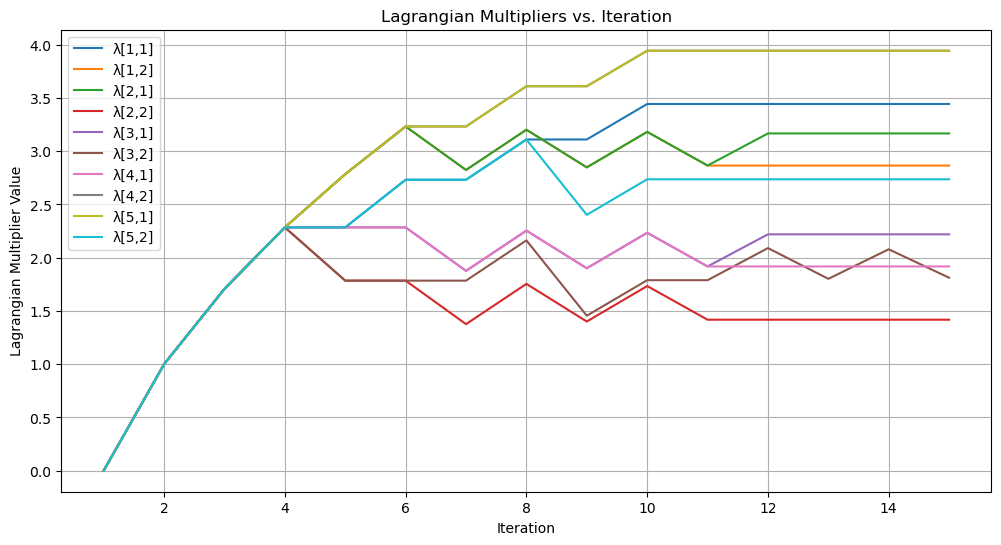

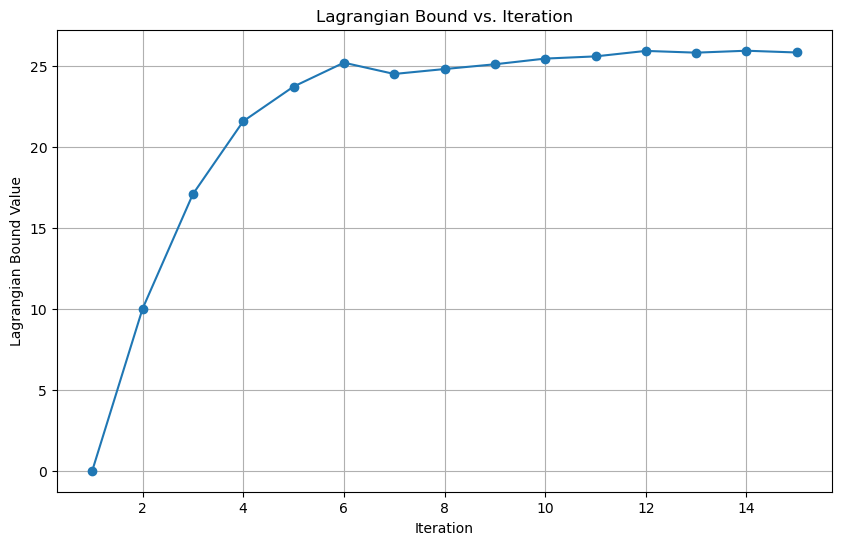

In [283]:
import matplotlib.pyplot as plt

# Plot 1: Lagrangian Multipliers vs Iteration
plt.figure(figsize=(12, 6))
for j in J:
    for k in K:
        plt.plot(iteration_numbers, lambda_history[j,k], label=f'λ[{j},{k}]')

plt.xlabel("Iteration")
plt.ylabel("Lagrangian Multiplier Value")
plt.title("Lagrangian Multipliers vs. Iteration")
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Plot 2: Lagrangian Bound vs Iteration
plt.figure(figsize=(10, 6))
plt.plot(iteration_numbers, lag_bound_history, marker='o', linestyle='-')
plt.xlabel("Iteration")
plt.ylabel("Lagrangian Bound Value")
plt.title("Lagrangian Bound vs. Iteration")
plt.grid(True)
plt.show()



# h) Branch and bound

In [300]:
import gurobipy as gp
from gurobipy import GRB

# --- 1) Data ---

I = [1, 2, 3]           # facilities
J = [1, 2, 3, 4, 5]     # clients
K = [1, 2]              # products

# routing costs c[i][j][k]
costs = {
  1: {1:{1:2, 2:4}, 2:{1:3, 2:1}, 3:{1:4, 2:2}, 4:{1:5, 2:5}, 5:{1:7, 2:2}},
  2: {1:{1:4, 2:3}, 2:{1:3, 2:1}, 3:{1:1, 2:1}, 4:{1:2, 2:5}, 5:{1:6, 2:3}},
  3: {1:{1:5, 2:2}, 2:{1:4, 2:5}, 3:{1:2, 2:2}, 4:{1:1, 2:3}, 5:{1:3, 2:3}}
}

# fixed opening costs f[i]
f = {1:2, 2:3, 3:3}

# --- 2) model ---

m = gp.Model()
m.Params.OutputFlag = 0 

# decision variables
x = {}
for i in I:
    for j in J:
        for k in K:
            # fraction of demand of (j,k) served by i
            x[i,j,k] = m.addVar(lb=0.0, ub=1.0, name=f"x_{i}_{j}_{k}")

y = {}
for i in I:
    y[i] = m.addVar(lb=0.0, ub=1.0, name=f"y_{i}") # relaxed variable 


# --- 3) Constraints ---

# cover each (j,k) by at least one facility
for j in J:
    for k in K:
        expr = 0
        for i in I:
            expr += x[i,j,k]
        m.addConstr(expr >= 1, name=f"cover_{j}_{k}")

# cannot serve unless open
for i in I:
    for j in J:
        for k in K:
            m.addConstr(x[i,j,k] <= y[i], name=f"link_{i}_{j}_{k}")

# --- 4) Objective ---

obj = 0
# routing costs
for i in I:
    for j in J:
        for k in K:
            obj += costs[i][j][k] * x[i,j,k]
# opening costs
for i in I:
    obj += f[i] * y[i]

m.setObjective(obj, GRB.MINIMIZE)

# --- 5) Optimize ---

m.optimize()

# --- 6) Report results ---

print("Optimal objective value:", m.ObjVal)
print("Open facilities:")
for i in I:
    if y[i].X > 0.5:
        print(" Facility", i)

print("Assignments x[i,j,k]:")
for i in I:
    for j in J:
        for k in K:
            val = x[i,j,k].X
            if val > 1e-6:
                print(f"  x[{i},{j},{k}] = {val:.2f}")



Optimal objective value: 26.0
Open facilities:
 Facility 1
 Facility 3
Assignments x[i,j,k]:
  x[1,1,1] = 1.00
  x[1,2,1] = 1.00
  x[1,2,2] = 1.00
  x[1,3,2] = 1.00
  x[1,5,2] = 1.00
  x[3,1,2] = 1.00
  x[3,3,1] = 1.00
  x[3,4,1] = 1.00
  x[3,4,2] = 1.00
  x[3,5,1] = 1.00


### The first iteration of the branch and bound method (just relaxing the problem) gives us the optimal and integer solution so we dont explore any other branch.

# i) Cutting planes technique

### As shown in the branch and bound question, with the LP Relaxation we already find the optimal and integer solution so there wont be any cuts that we need to add.